In [1]:
!pip install pandas-datareader
!pip install yfinance

In [5]:
import pandas as pd
import numpy as np
import datetime as dt
from pandas_datareader import data as pdr
import yfinance as yf

### Phase 1 : Data collection

In [6]:

# Stock data collection
# Importing data of 50 stocks

stocks = ["AAPL","MSFT","NVDA","AVGO","ORCL",
    "AMZN","TSLA","HD","MCD","BKNG",
    "META","GOOGL","NFLX","DIS",
    "PG","KO","PEP","COST",
    "UNH","JNJ","ABBV","LLY","MRK",
    "JPM","BAC","WFC","GS","MS","BLK",
    "CAT","GE","HON","UPS","BA","DE",
    "XOM","CVX","COP",
    "NEE","DUK",
    "PLD","AMT",
    "LIN","SHW","FCX","ECL",
    "AMD","CRM","TMUS","ISRG"]

data = yf.download(stocks, start='2016-01-01', end=None)

print(data)

[*********************100%***********************]  50 of 50 completed


Price            Close                                                  \
Ticker            AAPL        ABBV         AMD         AMT        AMZN   
Date                                                                     
2016-01-04   23.709105   37.132973    2.770000   74.226456   31.849501   
2016-01-05   23.114971   36.978279    2.750000   75.692566   31.689501   
2016-01-06   22.662617   36.984726    2.510000   75.423920   31.632500   
2016-01-07   21.706150   36.875145    2.280000   73.543320   30.396999   
2016-01-08   21.820929   35.869652    2.140000   72.330490   30.352501   
...                ...         ...         ...         ...         ...   
2026-07-27  336.910004  256.910004  494.950012  166.740005  231.389999   
2026-07-28  340.079987  263.200012  454.619995  171.500000  230.860001   
2026-07-29  338.190002  263.299988  429.559998  179.259995  226.649994   
2026-07-30  333.429993  257.410004  485.390015  174.460007  235.500000   
2026-07-31  308.910004  250.940002  47

In [8]:
print(data.head())

Price           Close                                                    \
Ticker           AAPL       ABBV   AMD        AMT       AMZN       AVGO   
Date                                                                      
2016-01-04  23.709105  37.132973  2.77  74.226456  31.849501  10.836731   
2016-01-05  23.114971  36.978279  2.75  75.692566  31.689501  10.474185   
2016-01-06  22.662617  36.984726  2.51  75.423920  31.632500  10.152010   
2016-01-07  21.706150  36.875145  2.28  73.543320  30.396999   9.829069   
2016-01-08  21.820929  35.869652  2.14  72.330490  30.352501   9.764330   

Price                                                     ...   Volume  \
Ticker              BA        BAC       BKNG         BLK  ...      PEP   
Date                                                      ...            
2016-01-04  126.005096  13.054464  48.778641  256.778656  ...  6689000   
2016-01-05  126.516312  13.054464  47.420296  257.441498  ...  4893800   
2016-01-06  124.507370  12.77

### Phase 2: Data Cleaning

In [9]:
close_prices = data['Close']
print(close_prices)

Ticker            AAPL        ABBV         AMD         AMT        AMZN  \
Date                                                                     
2016-01-04   23.709105   37.132973    2.770000   74.226456   31.849501   
2016-01-05   23.114971   36.978279    2.750000   75.692566   31.689501   
2016-01-06   22.662617   36.984726    2.510000   75.423920   31.632500   
2016-01-07   21.706150   36.875145    2.280000   73.543320   30.396999   
2016-01-08   21.820929   35.869652    2.140000   72.330490   30.352501   
...                ...         ...         ...         ...         ...   
2026-07-27  336.910004  256.910004  494.950012  166.740005  231.389999   
2026-07-28  340.079987  263.200012  454.619995  171.500000  230.860001   
2026-07-29  338.190002  263.299988  429.559998  179.259995  226.649994   
2026-07-30  333.429993  257.410004  485.390015  174.460007  235.500000   
2026-07-31  308.910004  250.940002  476.149994  173.360001  271.579987   

Ticker            AVGO          BA   

In [10]:
stock_prices = data.xs("Close", axis=1, level="Price")
stock_prices

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,23.709105,37.132973,2.770000,74.226456,31.849501,10.836731,126.005096,13.054464,48.778641,256.778656,...,71.665535,58.231102,30.973516,76.986435,37.247654,14.894000,97.893661,63.806992,39.475052,49.319618
2016-01-05,23.114971,36.978279,2.750000,75.692566,31.689501,10.474185,126.516312,13.054464,47.420296,257.441498,...,72.158913,58.416859,31.624039,77.297714,38.462147,14.895333,98.078583,64.439400,39.460136,49.739853
2016-01-06,22.662617,36.984726,2.510000,75.423920,31.632500,10.152010,124.507370,12.776369,46.872726,254.512253,...,72.180695,57.852158,31.454023,75.061424,38.299568,14.602667,97.078308,63.524406,38.706589,49.325970
2016-01-07,21.706150,36.875145,2.280000,73.543320,30.396999,9.829069,119.287827,12.315529,45.716488,243.388657,...,70.794846,57.346897,30.633478,73.003403,38.739464,14.376667,94.220329,62.299938,37.602402,48.536461
2016-01-08,21.820929,35.869652,2.140000,72.330490,30.352501,9.764330,116.579391,12.077164,44.532440,237.260162,...,70.533661,56.447823,30.359968,73.063828,38.137001,14.066667,92.598061,61.485874,36.975693,47.555920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-27,336.910004,256.910004,494.950012,166.740005,231.389999,383.220001,211.500000,62.130001,186.789993,1062.140015,...,139.789993,148.630005,147.259995,327.269989,177.210007,309.220001,417.640015,112.949997,87.269997,154.770004
2026-07-28,340.079987,263.200012,454.619995,171.500000,230.860001,380.910004,221.559998,62.619999,199.309998,1097.550049,...,142.860001,148.880005,147.119995,354.269989,182.389999,307.440002,428.790009,105.529999,86.870003,153.039993
2026-07-29,338.190002,263.299988,429.559998,179.259995,226.649994,370.320007,214.009995,61.070000,201.300003,1079.189941,...,143.500000,146.100006,145.470001,343.880005,181.520004,298.320007,420.570007,104.559998,83.870003,156.750000


In [11]:
stock_prices.head()

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,23.709105,37.132973,2.77,74.226456,31.849501,10.836731,126.005096,13.054464,48.778641,256.778656,...,71.665535,58.231102,30.973516,76.986435,37.247654,14.894000,97.893661,63.806992,39.475052,49.319618
2016-01-05,23.114971,36.978279,2.75,75.692566,31.689501,10.474185,126.516312,13.054464,47.420296,257.441498,...,72.158913,58.416859,31.624039,77.297714,38.462147,14.895333,98.078583,64.439400,39.460136,49.739853
2016-01-06,22.662617,36.984726,2.51,75.423920,31.632500,10.152010,124.507370,12.776369,46.872726,254.512253,...,72.180695,57.852158,31.454023,75.061424,38.299568,14.602667,97.078308,63.524406,38.706589,49.325970
2016-01-07,21.706150,36.875145,2.28,73.543320,30.396999,9.829069,119.287827,12.315529,45.716488,243.388657,...,70.794846,57.346897,30.633478,73.003403,38.739464,14.376667,94.220329,62.299938,37.602402,48.536461
2016-01-08,21.820929,35.869652,2.14,72.330490,30.352501,9.764330,116.579391,12.077164,44.532440,237.260162,...,70.533661,56.447823,30.359968,73.063828,38.137001,14.066667,92.598061,61.485874,36.975693,47.555920


In [12]:

benchmark = "SPY"

start_date = "2015-01-01"
end_date = None
import yfinance as yf

benchmark = "SPY"

benchmark_data = yf.download(
    benchmark,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

benchmark_prices = benchmark_data["Close"]
benchmark_prices.name = "SPY"
print(benchmark_data)

Price            Close        High         Low        Open     Volume
Ticker             SPY         SPY         SPY         SPY        SPY
Date                                                                 
2015-01-02  169.687851  170.885580  168.655335  170.472573  121465900
2015-01-05  166.623367  168.812297  166.317746  168.647097  169632600
2015-01-06  165.053925  167.449357  164.260947  166.928965  209151400
2015-01-07  167.110672  167.449340  165.929480  166.375521  125346700
2015-01-08  170.076065  170.290837  168.498390  168.514901  147217800
...                ...         ...         ...         ...        ...
2026-07-27  739.090027  745.530029  735.869995  744.909973   41461200
2026-07-28  740.859985  742.789978  735.979980  739.190002   47322200
2026-07-29  729.460022  742.679993  729.099976  739.969971   70697200
2026-07-30  741.690002  742.450012  734.590027  736.049988   66811300
2026-07-31  747.030029  748.900024  737.679993  744.679993   62339900

[2911 rows x 5 colu

In [13]:
Benchmark_close_prices = benchmark_data["Close"]
Benchmark_close_prices

Ticker,SPY
Date,
2015-01-02,169.687851
2015-01-05,166.623367
2015-01-06,165.053925
2015-01-07,167.110672
2015-01-08,170.076065
...,...
2026-07-27,739.090027
2026-07-28,740.859985
2026-07-29,729.460022


In [14]:
stock_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2659 entries, 2016-01-04 to 2026-07-31
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2659 non-null   float64
 1   ABBV    2659 non-null   float64
 2   AMD     2659 non-null   float64
 3   AMT     2659 non-null   float64
 4   AMZN    2659 non-null   float64
 5   AVGO    2659 non-null   float64
 6   BA      2659 non-null   float64
 7   BAC     2659 non-null   float64
 8   BKNG    2659 non-null   float64
 9   BLK     2659 non-null   float64
 10  CAT     2659 non-null   float64
 11  COP     2659 non-null   float64
 12  COST    2659 non-null   float64
 13  CRM     2659 non-null   float64
 14  CVX     2659 non-null   float64
 15  DE      2659 non-null   float64
 16  DIS     2659 non-null   float64
 17  DUK     2659 non-null   float64
 18  ECL     2659 non-null   float64
 19  FCX     2659 non-null   float64
 20  GE      2659 non-null   float64
 21  GOOGL   2659 non-nu

In [16]:
stock_prices.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,2659.0,123.154876,80.817419,20.565866,42.730818,127.208015,180.741539,340.079987
ABBV,2659.0,107.069889,56.571126,33.334946,61.094275,89.360046,143.676773,263.299988
AMD,2659.0,88.238191,89.099806,1.800000,18.830000,79.349998,119.215000,580.909973
AMT,2659.0,166.369939,46.985642,64.217010,119.089447,177.521011,200.859947,259.693481
AMZN,2659.0,126.908898,62.283433,24.103500,82.052998,121.683998,172.338501,274.989990
AVGO,2659.0,85.642708,104.579916,8.858730,20.120579,41.882969,94.709705,480.809052
BA,2659.0,219.401294,73.201262,95.010002,168.618324,207.559998,245.123627,430.299957
BAC,2659.0,29.877951,11.156832,8.867180,22.407996,27.210915,37.177256,62.619999
BKNG,2659.0,102.612033,48.415579,38.141788,70.601288,81.375801,126.518486,230.685989


In [17]:
Benchmark_close_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2911 entries, 2015-01-02 to 2026-07-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     2911 non-null   float64
dtypes: float64(1)
memory usage: 45.5 KB


In [18]:
Benchmark_close_prices.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
SPY,2911.0,354.620122,158.715464,154.161621,224.412811,317.637238,435.45076,757.618225


In [19]:
returns= np.log(stock_prices / stock_prices.shift(1)) # For calculating returns for each stocks
returns
    

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,-0.025379,-0.004175,-0.007246,0.019559,-0.005036,-0.034028,0.004049,0.000000,-0.028242,0.002578,...,0.006861,0.003185,0.020785,0.004035,0.032086,0.000090,0.001887,0.009862,-0.000378,0.008485
2016-01-06,-0.019764,0.000174,-0.091318,-0.003555,-0.001800,-0.031242,-0.016006,-0.021533,-0.011614,-0.011444,...,0.000302,-0.009714,-0.005391,-0.029358,-0.004236,-0.019844,-0.010251,-0.014301,-0.019281,-0.008356
2016-01-07,-0.043121,-0.002967,-0.096107,-0.025250,-0.039841,-0.032327,-0.042826,-0.036736,-0.024977,-0.044689,...,-0.019386,-0.008772,-0.026433,-0.027801,0.011420,-0.015598,-0.029882,-0.019464,-0.028942,-0.016135
2016-01-08,0.005274,-0.027646,-0.063370,-0.016629,-0.001465,-0.006608,-0.022967,-0.019545,-0.026241,-0.025502,...,-0.003696,-0.015802,-0.008969,0.000827,-0.015674,-0.021799,-0.017368,-0.013153,-0.016807,-0.020409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-27,0.011613,-0.009491,-0.053115,0.000420,-0.003107,0.003398,0.009406,0.001288,0.051240,0.006110,...,0.022792,0.008242,-0.002509,0.030276,-0.016121,-0.012246,-0.007395,-0.016159,0.011061,-0.013923
2026-07-28,0.009365,0.024188,-0.084995,0.028148,-0.002293,-0.006046,0.046468,0.007856,0.064876,0.032795,...,0.021724,0.001681,-0.000951,0.079274,0.028812,-0.005773,0.026347,-0.067950,-0.004594,-0.011241
2026-07-29,-0.005573,0.000380,-0.056700,0.044254,-0.018405,-0.028196,-0.034671,-0.025064,0.009935,-0.016870,...,0.004470,-0.018849,-0.011279,-0.029767,-0.004781,-0.030113,-0.019356,-0.009234,-0.035145,0.023953


In [20]:
returns = returns.dropna() # Removing NaN values
returns

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-05,-0.025379,-0.004175,-0.007246,0.019559,-0.005036,-0.034028,0.004049,0.000000,-0.028242,0.002578,...,0.006861,0.003185,0.020785,0.004035,0.032086,0.000090,0.001887,0.009862,-0.000378,0.008485
2016-01-06,-0.019764,0.000174,-0.091318,-0.003555,-0.001800,-0.031242,-0.016006,-0.021533,-0.011614,-0.011444,...,0.000302,-0.009714,-0.005391,-0.029358,-0.004236,-0.019844,-0.010251,-0.014301,-0.019281,-0.008356
2016-01-07,-0.043121,-0.002967,-0.096107,-0.025250,-0.039841,-0.032327,-0.042826,-0.036736,-0.024977,-0.044689,...,-0.019386,-0.008772,-0.026433,-0.027801,0.011420,-0.015598,-0.029882,-0.019464,-0.028942,-0.016135
2016-01-08,0.005274,-0.027646,-0.063370,-0.016629,-0.001465,-0.006608,-0.022967,-0.019545,-0.026241,-0.025502,...,-0.003696,-0.015802,-0.008969,0.000827,-0.015674,-0.021799,-0.017368,-0.013153,-0.016807,-0.020409
2016-01-11,0.016062,-0.032323,0.089345,0.002650,0.017456,-0.001249,0.001691,0.007211,-0.000598,0.001753,...,0.002363,0.009172,-0.001218,0.000827,-0.005028,-0.015041,-0.005279,0.002950,0.010637,-0.013479
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-27,0.011613,-0.009491,-0.053115,0.000420,-0.003107,0.003398,0.009406,0.001288,0.051240,0.006110,...,0.022792,0.008242,-0.002509,0.030276,-0.016121,-0.012246,-0.007395,-0.016159,0.011061,-0.013923
2026-07-28,0.009365,0.024188,-0.084995,0.028148,-0.002293,-0.006046,0.046468,0.007856,0.064876,0.032795,...,0.021724,0.001681,-0.000951,0.079274,0.028812,-0.005773,0.026347,-0.067950,-0.004594,-0.011241
2026-07-29,-0.005573,0.000380,-0.056700,0.044254,-0.018405,-0.028196,-0.034671,-0.025064,0.009935,-0.016870,...,0.004470,-0.018849,-0.011279,-0.029767,-0.004781,-0.030113,-0.019356,-0.009234,-0.035145,0.023953


In [21]:
meanReturns = returns.mean()
meanReturns

Ticker
AAPL     0.000966
ABBV     0.000719
AMD      0.001936
AMT      0.000319
AMZN     0.000806
AVGO     0.001347
BA       0.000203
BAC      0.000586
BKNG     0.000517
BLK      0.000544
CAT      0.001029
COP      0.000476
COST     0.000739
CRM      0.000336
CVX      0.000467
DE       0.000837
DIS      0.000008
DUK      0.000374
ECL      0.000383
FCX      0.000889
GE       0.000384
GOOGL    0.000845
GS       0.000739
HD       0.000445
HON      0.000429
ISRG     0.000662
JNJ      0.000461
JPM      0.000748
KO       0.000396
LIN      0.000651
LLY      0.001055
MCD      0.000410
META     0.000641
MRK      0.000481
MS       0.000827
MSFT     0.000856
NEE      0.000557
NFLX     0.000705
NVDA     0.002084
ORCL     0.000544
PEP      0.000251
PG       0.000342
PLD      0.000580
SHW      0.000560
TMUS     0.000577
TSLA     0.001144
UNH      0.000543
UPS      0.000185
WFC      0.000295
XOM      0.000432
dtype: float64

In [22]:
returns.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,2658.0,0.000966,0.018255,-0.137708,-0.007152,0.001095,0.009976,0.142617
ABBV,2658.0,0.000719,0.016564,-0.177363,-0.006827,0.001066,0.008773,0.128985
AMD,2658.0,0.001936,0.037262,-0.277456,-0.017383,0.000769,0.020646,0.420617
AMT,2658.0,0.000319,0.016457,-0.164448,-0.007585,0.000795,0.008825,0.115308
AMZN,2658.0,0.000806,0.020758,-0.151398,-0.008978,0.001153,0.011552,0.142546
AVGO,2658.0,0.001347,0.024799,-0.222056,-0.010453,0.001370,0.013604,0.218594
BA,2658.0,0.000203,0.025923,-0.272444,-0.010466,0.000465,0.011449,0.217677
BAC,2658.0,0.000586,0.019404,-0.167205,-0.008446,0.000663,0.010379,0.163786
BKNG,2658.0,0.000517,0.020644,-0.145254,-0.008938,0.001063,0.010609,0.171868


In [23]:
print(returns.isna().sum()) # For checking is there any NaN value present 

Ticker
AAPL     0
ABBV     0
AMD      0
AMT      0
AMZN     0
AVGO     0
BA       0
BAC      0
BKNG     0
BLK      0
CAT      0
COP      0
COST     0
CRM      0
CVX      0
DE       0
DIS      0
DUK      0
ECL      0
FCX      0
GE       0
GOOGL    0
GS       0
HD       0
HON      0
ISRG     0
JNJ      0
JPM      0
KO       0
LIN      0
LLY      0
MCD      0
META     0
MRK      0
MS       0
MSFT     0
NEE      0
NFLX     0
NVDA     0
ORCL     0
PEP      0
PG       0
PLD      0
SHW      0
TMUS     0
TSLA     0
UNH      0
UPS      0
WFC      0
XOM      0
dtype: int64


In [26]:
print(Benchmark_returns.isna().sum())

Ticker
SPY    1
dtype: int64


In [25]:
Benchmark_returns= np.log(Benchmark_close_prices / Benchmark_close_prices.shift(1))# For calculating returns for benchmark
Benchmark_returns
    

Ticker,SPY
Date,
2015-01-02,NaN
2015-01-05,-0.018225
2015-01-06,-0.009464
2015-01-07,0.012384
2015-01-08,0.017589
...,...
2026-07-27,0.000217
2026-07-28,0.002392
2026-07-29,-0.015507


In [27]:
Benchmark_returns.dropna()

Ticker,SPY
Date,
2015-01-05,-0.018225
2015-01-06,-0.009464
2015-01-07,0.012384
2015-01-08,0.017589
2015-01-09,-0.008046
...,...
2026-07-27,0.000217
2026-07-28,0.002392
2026-07-29,-0.015507


In [28]:
stale = stock_prices.diff() == 0 # A stale price means the stock price didn't change for several consecutive trading days.
stale

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2016-01-05,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2016-01-06,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2016-01-07,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2016-01-08,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-27,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2026-07-28,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2026-07-29,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [29]:
weights = np.ones(len(returns.columns)) / len(returns.columns) #Building weighted portions for 50 stocks
weights

array([0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02])

In [30]:
# Weighted portfolio return series
portfolio_returns_50stocks = returns.dot(weights)
portfolio_returns_50stocks


Date
2016-01-05    0.001898
2016-01-06   -0.014162
2016-01-07   -0.028611
2016-01-08   -0.013358
2016-01-11   -0.002088
                ...   
2026-07-27    0.003746
2026-07-28    0.008909
2026-07-29   -0.012367
2026-07-30    0.004741
2026-07-31    0.001331
Length: 2658, dtype: float64

In [33]:
portfolio_returns = meanReturns.dot(weights)*252 # Expected annual portfolio return for 50 stocks
print(portfolio_returns)

0.1628422266016181


In [34]:
print(portfolio_returns.index.min())
print(portfolio_returns.index.max())

AttributeError: 'numpy.float64' object has no attribute 'index'

In [35]:

import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf

In [36]:
mean_returns = portfolio_returns.mean()
print(mean_returns)

0.1628422266016181


In [37]:
# Covariance matrix
covMatrix = returns.cov()
covMatrix

Ticker,AAPL,ABBV,AMD,AMT,AMZN,AVGO,BA,BAC,BKNG,BLK,...,PEP,PG,PLD,SHW,TMUS,TSLA,UNH,UPS,WFC,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0.000333,0.000081,0.000288,0.000098,0.000207,0.000228,0.000188,0.000146,0.000157,0.000172,...,0.000087,0.000073,0.000141,0.000129,0.000106,0.000291,0.000100,0.000129,0.000131,0.000090
ABBV,0.000081,0.000274,0.000086,0.000072,0.000057,0.000074,0.000095,0.000097,0.000073,0.000095,...,0.000069,0.000062,0.000084,0.000085,0.000074,0.000069,0.000101,0.000078,0.000093,0.000079
AMD,0.000288,0.000086,0.001388,0.000093,0.000334,0.000441,0.000276,0.000207,0.000226,0.000246,...,0.000061,0.000051,0.000182,0.000172,0.000132,0.000512,0.000127,0.000187,0.000179,0.000103
AMT,0.000098,0.000072,0.000093,0.000271,0.000076,0.000073,0.000106,0.000086,0.000078,0.000119,...,0.000101,0.000088,0.000167,0.000113,0.000088,0.000088,0.000085,0.000082,0.000079,0.000056
AMZN,0.000207,0.000057,0.000334,0.000076,0.000431,0.000232,0.000165,0.000126,0.000176,0.000163,...,0.000051,0.000046,0.000124,0.000115,0.000101,0.000312,0.000078,0.000120,0.000114,0.000055
AVGO,0.000228,0.000074,0.000441,0.000073,0.000232,0.000615,0.000242,0.000176,0.000200,0.000208,...,0.000059,0.000042,0.000139,0.000156,0.000101,0.000378,0.000098,0.000124,0.000161,0.000101
BA,0.000188,0.000095,0.000276,0.000106,0.000165,0.000242,0.000672,0.000259,0.000262,0.000221,...,0.000083,0.000067,0.000172,0.000152,0.000112,0.000300,0.000135,0.000137,0.000267,0.000189
BAC,0.000146,0.000097,0.000207,0.000086,0.000126,0.000176,0.000259,0.000377,0.000198,0.000229,...,0.000071,0.000064,0.000141,0.000134,0.000106,0.000201,0.000124,0.000144,0.000325,0.000174
BKNG,0.000157,0.000073,0.000226,0.000078,0.000176,0.000200,0.000262,0.000198,0.000426,0.000180,...,0.000065,0.000055,0.000116,0.000119,0.000110,0.000221,0.000098,0.000109,0.000196,0.000119


In [38]:
portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(covMatrix * 252, weights)))
print(portfolio_volatility)

0.1837695747273437


### Phase 3: Portfolio Construction

In [39]:
# Daily portfolio value
initial_portfolio_value = 1000000

portfolio_returns = returns.dot(weights)

portfolio_value = initial_portfolio_value * (1 + portfolio_returns).cumprod()

print(portfolio_value)

Date
2016-01-05    1.001898e+06
2016-01-06    9.877090e+05
2016-01-07    9.594501e+05
2016-01-08    9.466339e+05
2016-01-11    9.446578e+05
                  ...     
2026-07-27    4.642794e+06
2026-07-28    4.684156e+06
2026-07-29    4.626228e+06
2026-07-30    4.648160e+06
2026-07-31    4.654346e+06
Length: 2658, dtype: float64


In [40]:
# Daily portfolio P&L

portfolio_pnl = portfolio_value.diff()
portfolio_pnl

Date
2016-01-05             NaN
2016-01-06   -14188.593749
2016-01-07   -28258.848316
2016-01-08   -12816.197238
2016-01-11    -1976.102710
                  ...     
2026-07-27    17327.785184
2026-07-28    41361.938218
2026-07-29   -57927.831309
2026-07-30    21931.505210
2026-07-31     6186.299557
Length: 2658, dtype: float64

In [41]:
# daily portfolio returns
portfolio_returns = returns.dot(weights)
portfolio_returns

Date
2016-01-05    0.001898
2016-01-06   -0.014162
2016-01-07   -0.028611
2016-01-08   -0.013358
2016-01-11   -0.002088
                ...   
2026-07-27    0.003746
2026-07-28    0.008909
2026-07-29   -0.012367
2026-07-30    0.004741
2026-07-31    0.001331
Length: 2658, dtype: float64

### Phase 4:- Historical Simulation VaR

In [42]:
portfolio_pnl

Date
2016-01-05             NaN
2016-01-06   -14188.593749
2016-01-07   -28258.848316
2016-01-08   -12816.197238
2016-01-11    -1976.102710
                  ...     
2026-07-27    17327.785184
2026-07-28    41361.938218
2026-07-29   -57927.831309
2026-07-30    21931.505210
2026-07-31     6186.299557
Length: 2658, dtype: float64

In [43]:
pnl = portfolio_pnl.dropna()
pnl

Date
2016-01-06   -14188.593749
2016-01-07   -28258.848316
2016-01-08   -12816.197238
2016-01-11    -1976.102710
2016-01-12     7359.650873
                  ...     
2026-07-27    17327.785184
2026-07-28    41361.938218
2026-07-29   -57927.831309
2026-07-30    21931.505210
2026-07-31     6186.299557
Length: 2657, dtype: float64

In [44]:
pnl.head()

Date
2016-01-06   -14188.593749
2016-01-07   -28258.848316
2016-01-08   -12816.197238
2016-01-11    -1976.102710
2016-01-12     7359.650873
dtype: float64

In [45]:
pnl.describe()

count      2657.000000
mean       1374.651351
std       26822.001255
min     -229348.702458
25%       -8554.711898
50%        1816.171831
75%       14030.097090
max      278921.997568
dtype: float64

In [75]:
# Calculation of VaR

var_95 = -np.percentile(pnl, 5)
var_99 = -np.percentile(pnl, 1)
var_995 = -np.percentile(pnl, 0.5)

print(f"95% VaR: ₹{var_95:,.2f}")
print(f"99% VaR: ₹{var_99:,.2f}")
print(f"99.5% VaR: ₹{var_995:,.2f}")

95% VaR: ₹43,549.11
99% VaR: ₹76,104.10
99.5% VaR: ₹94,694.10


### Calculate 250-day rolling VaR (95% confidential level)

In [47]:
rolling_var_250_95 = -pnl.rolling(window=250).quantile(0.05)
rolling_var_250_95

Date
2016-01-06             NaN
2016-01-07             NaN
2016-01-08             NaN
2016-01-11             NaN
2016-01-12             NaN
                  ...     
2026-07-27    56522.685570
2026-07-28    56522.685570
2026-07-29    58100.647632
2026-07-30    58100.647632
2026-07-31    58100.647632
Length: 2657, dtype: float64

In [48]:
print(rolling_var_250_95.head(260))

Date
2016-01-06             NaN
2016-01-07             NaN
2016-01-08             NaN
2016-01-11             NaN
2016-01-12             NaN
                  ...     
2017-01-10    13846.169445
2017-01-11    13846.169445
2017-01-12    13264.855110
2017-01-13    13264.855110
2017-01-17    13264.855110
Length: 260, dtype: float64


In [49]:
### Look at the latest VaR

print("Latest 250-day 95% VaR:",f"₹{rolling_var_250_95.iloc[-1]:,.2f}")

Latest 250-day 95% VaR: ₹58,100.65


In [50]:
print(rolling_var_250_95.tail())

Date
2026-07-27    56522.685570
2026-07-28    56522.685570
2026-07-29    58100.647632
2026-07-30    58100.647632
2026-07-31    58100.647632
dtype: float64


### Calculate 250-day rolling VaR (99% confidential level)

In [51]:
rolling_var_250_99 = -pnl.rolling(window=250).quantile(0.01)

print(rolling_var_250_99.tail())

Date
2026-07-27    64837.252504
2026-07-28    64837.252504
2026-07-29    64837.252504
2026-07-30    64837.252504
2026-07-31    64837.252504
dtype: float64


In [52]:
print("Latest 250-day 99% VaR:",f"₹{rolling_var_250_99.iloc[-1]:,.2f}")

Latest 250-day 99% VaR: ₹64,837.25


### Calculate 250-day rolling VaR (99.5% confidential level)

In [53]:
rolling_var_250_995 = -pnl.rolling(window=250).quantile(0.005)

print(rolling_var_250_995.tail())

Date
2026-07-27    67873.377937
2026-07-28    67873.377937
2026-07-29    67873.377937
2026-07-30    67873.377937
2026-07-31    67873.377937
dtype: float64


In [54]:
print("Latest 250-day 99.5% VaR:",f"₹{rolling_var_250_995.iloc[-1]:,.2f}")

Latest 250-day 99.5% VaR: ₹67,873.38


### Calculate 500-day rolling VaR (95% confidential level)

In [55]:
rolling_var_500_95 = -pnl.rolling(window=500).quantile(0.05)

print(rolling_var_500_95.tail())

Date
2026-07-27    60676.219193
2026-07-28    60676.219193
2026-07-29    60676.219193
2026-07-30    60676.219193
2026-07-31    60676.219193
dtype: float64


In [56]:
print("Latest 500-day 95% VaR:",f"₹{rolling_var_500_95.iloc[-1]:,.2f}")

Latest 500-day 95% VaR: ₹60,676.22


### Calculate 500-day rolling VaR (99% confidential level)

In [57]:
rolling_var_500_99 = -pnl.rolling(window=500).quantile(0.01)

print(rolling_var_500_99.tail())

Date
2026-07-27    87627.111916
2026-07-28    87627.111916
2026-07-29    87627.111916
2026-07-30    87627.111916
2026-07-31    87627.111916
dtype: float64


In [58]:
print("Latest 500-day 99% VaR:",f"₹{rolling_var_500_99.iloc[-1]:,.2f}")

Latest 500-day 99% VaR: ₹87,627.11


### Calculate 500-day rolling VaR (99.9% confidential level)

In [59]:

rolling_var_500_995 = -pnl.rolling(window=500).quantile(0.005)

print(rolling_var_500_995.tail())

Date
2026-07-27    119946.757576
2026-07-28    119946.757576
2026-07-29    119946.757576
2026-07-30    119946.757576
2026-07-31    119946.757576
dtype: float64


In [60]:
print("Latest 500-day 99.9% VaR:",f"₹{rolling_var_500_995.iloc[-1]:,.2f}")

Latest 500-day 99.9% VaR: ₹119,946.76


### Calculate 750-day rolling VaR (95% confidential level)

In [61]:
rolling_var_750_95 = -pnl.rolling(window=750).quantile(0.05)

print(rolling_var_750_95.tail())

Date
2026-07-27    51326.753044
2026-07-28    51326.753044
2026-07-29    52076.918620
2026-07-30    52076.918620
2026-07-31    52076.918620
dtype: float64


In [115]:
print("Latest 750-day 95% VaR:",f"₹{rolling_var_750_95.iloc[-1]:,.2f}")

Latest 750-day 95% VaR: ₹52,076.93


### Calculate 750-day rolling VaR (99% confidential level)

In [63]:
rolling_var_750_99 = -pnl.rolling(window=750).quantile(0.01)

print(rolling_var_750_99.tail())

Date
2026-07-27    75188.037866
2026-07-28    75188.037866
2026-07-29    75188.037866
2026-07-30    75188.037866
2026-07-31    75188.037866
dtype: float64


In [64]:
print("Latest 750-day 99% VaR:",f"₹{rolling_var_750_99.iloc[-1]:,.2f}")

Latest 750-day 99% VaR: ₹75,188.04


In [65]:
rolling_var_750_995 = -pnl.rolling(window=750).quantile(0.005)

print(rolling_var_750_995.tail())

Date
2026-07-27    99836.971774
2026-07-28    99836.971774
2026-07-29    99836.971774
2026-07-30    99836.971774
2026-07-31    99836.971774
dtype: float64


In [66]:
print("Latest 750-day 99.5% VaR:",f"₹{rolling_var_750_995.iloc[-1]:,.2f}")

Latest 750-day 99.5% VaR: ₹99,836.97


### Calculate 95% Expected Shortfall

In [67]:
var_95_threshold = np.percentile(pnl, 5)
es_95 = -pnl[pnl <= var_95_threshold].mean()
print(f"95% Expected Shortfall: ₹{es_95:,.2f}")

95% Expected Shortfall: ₹67,513.64


### Calculate 99% Expected Shortfall

In [68]:
var_99_threshold = np.percentile(pnl, 1)

es_99 = -pnl[pnl <= var_99_threshold].mean()

print(f"99% Expected Shortfall: ₹{es_99:,.2f}")

99% Expected Shortfall: ₹113,292.69


### Calculate 99.5% Expected Shortfall

In [74]:
var_995_threshold = np.percentile(pnl, 0.5)

es_995 = -pnl[pnl <= var_995_threshold].mean()

print(f"99.5% Expected Shortfall: ₹{es_995:,.2f}")

99.5% Expected Shortfall: ₹139,582.29


In [70]:
import matplotlib.pyplot as plt

In [71]:
portfolio_returns

Date
2016-01-05    0.001898
2016-01-06   -0.014162
2016-01-07   -0.028611
2016-01-08   -0.013358
2016-01-11   -0.002088
                ...   
2026-07-27    0.003746
2026-07-28    0.008909
2026-07-29   -0.012367
2026-07-30    0.004741
2026-07-31    0.001331
Length: 2658, dtype: float64

### Historical Return Distribution

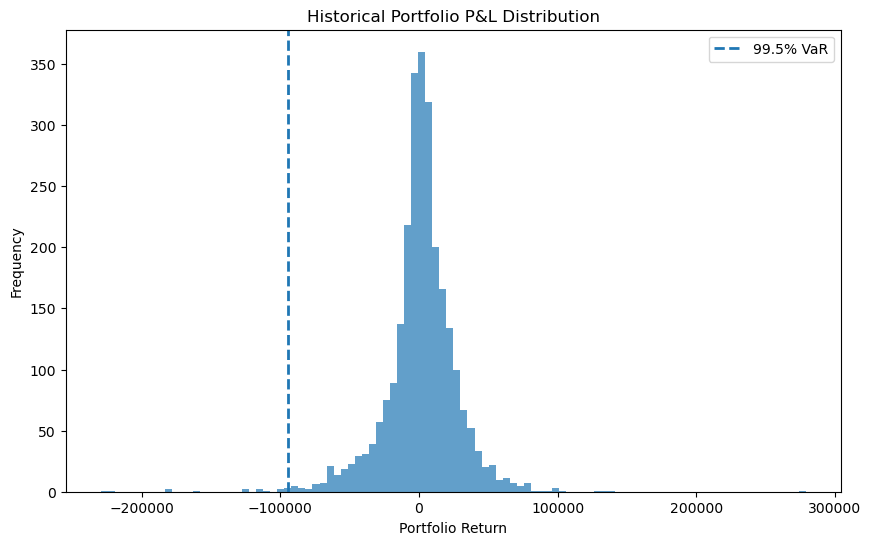

In [87]:
plt.figure(figsize=(10, 6))

plt.hist(pnl, bins=100, alpha=0.7)

plt.axvline(-var_995, linestyle='--', linewidth=2,
            label='99.5% VaR')

plt.title('Historical Portfolio P&L Distribution')
plt.xlabel('Portfolio Return')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [82]:
print("Portfolio_returns:")
print(portfolio_returns.describe())

print("\n99.5% VaR:")
print(var_995)

Portfolio_returns:
count    2658.000000
mean        0.000646
std         0.011576
min        -0.136941
25%        -0.003581
50%         0.000997
75%         0.005998
max         0.108666
dtype: float64

99.5% VaR:
94694.10215578527


In [83]:
print(portfolio_returns.head())

Date
2016-01-05    0.001898
2016-01-06   -0.014162
2016-01-07   -0.028611
2016-01-08   -0.013358
2016-01-11   -0.002088
dtype: float64


### VaR Threshold Line

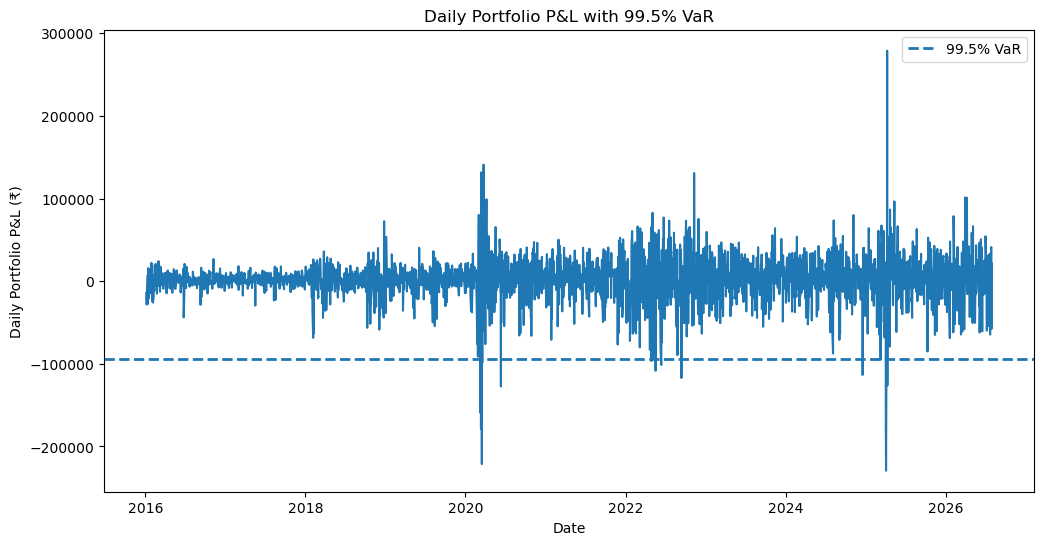

In [89]:
plt.figure(figsize=(12, 6))

plt.plot(pnl.index,pnl)

plt.axhline(-var_995, linestyle='--', linewidth=2,
            label='99.5% VaR')

plt.title('Daily Portfolio P&L with 99.5% VaR')
plt.xlabel('Date')
plt.ylabel('Daily Portfolio P&L (₹)')
plt.legend()

plt.show()

### Rolling VaR

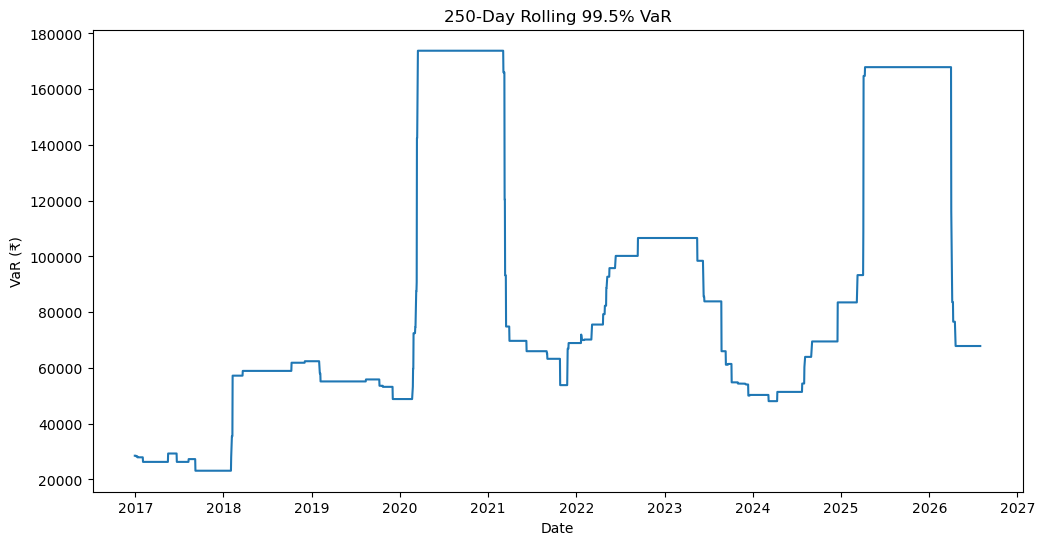

In [90]:
rolling_window = 250

rolling_var_995 = pnl.rolling(rolling_window).quantile(0.005)

plt.figure(figsize=(12, 6))

plt.plot(rolling_var_995.index, -rolling_var_995)

plt.title('250-Day Rolling 99.5% VaR')
plt.xlabel('Date')
plt.ylabel('VaR (₹)')

plt.show()

### Tail Loss Chart

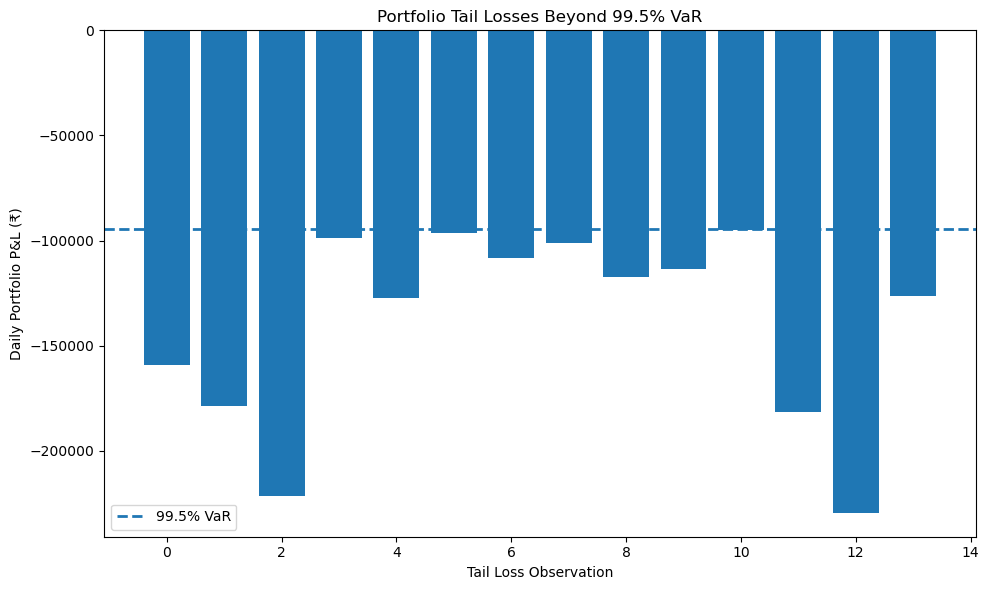

In [91]:
tail_losses = pnl[portfolio_pnl <= -var_995]

plt.figure(figsize=(10, 6))

plt.bar(range(len(tail_losses)), tail_losses)

plt.axhline(-var_995, linestyle='--', linewidth=2,
            label='99.5% VaR')

plt.title('Portfolio Tail Losses Beyond 99.5% VaR')
plt.xlabel('Tail Loss Observation')
plt.ylabel('Daily Portfolio P&L (₹)')
plt.legend()

plt.tight_layout()
plt.show()

### VaR vs Expected Shortfall

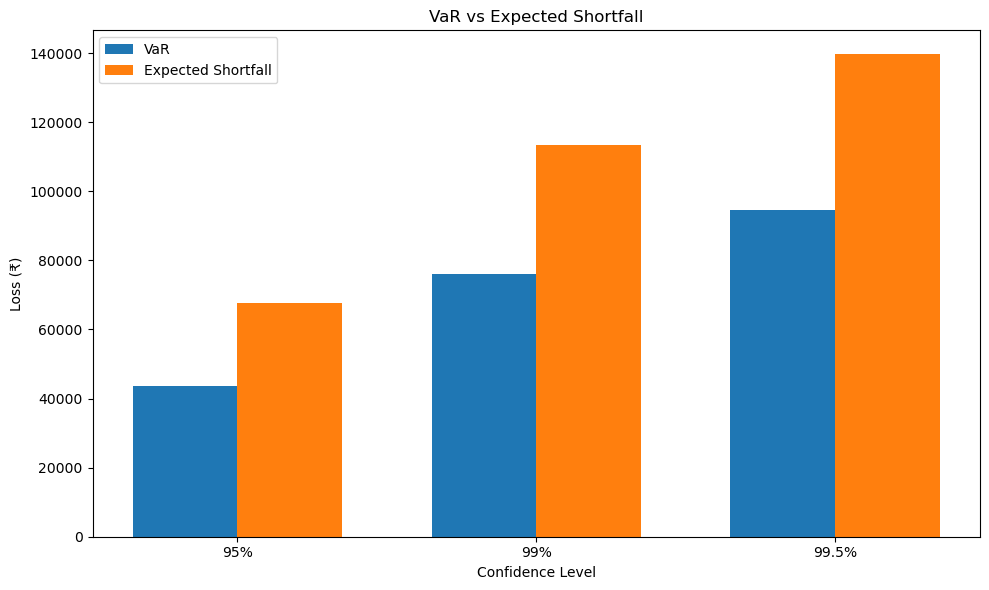

In [93]:
confidence_levels = ['95%', '99%', '99.5%']

VaR_values = [
    var_95,
    var_99,
    var_995 ]

ES_values = [
    es_95,
    es_99,
    es_995
]

x = np.arange(len(confidence_levels))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, VaR_values, width, label='VaR')
plt.bar(x + width/2, ES_values, width, label='Expected Shortfall')

plt.xticks(x, confidence_levels)
plt.xlabel('Confidence Level')
plt.ylabel('Loss (₹)')
plt.title('VaR vs Expected Shortfall')
plt.legend()

plt.tight_layout()
plt.show()

### Phase 5 – EWMA Volatility Scaling

In [94]:
lambda_ = 0.94

ewma_variance = portfolio_returns.pow(2).ewm(alpha=1 - lambda_).mean()

print(ewma_variance.head())

Date
2016-01-05    0.000004
2016-01-06    0.000105
2016-01-07    0.000358
2016-01-08    0.000309
2016-01-11    0.000240
dtype: float64


### Calculate EWMA Volatility

In [95]:
ewma_volatility = np.sqrt(ewma_variance)

print(ewma_volatility.head())

Date
2016-01-05    0.001898
2016-01-06    0.010253
2016-01-07    0.018915
2016-01-08    0.017570
2016-01-11    0.015495
dtype: float64


### Volatility-scaled historical returns

In [98]:
current_volatility = ewma_volatility.iloc[-1]

scaled_returns = portfolio_returns * (current_volatility / ewma_volatility)

print(scaled_returns.tail())

Date
2026-07-27    0.003861
2026-07-28    0.009005
2026-07-29   -0.011786
2026-07-30    0.004601
2026-07-31    0.001331
dtype: float64


### EWMA-scaled Historical VaR

In [100]:
scaled_pnl = scaled_returns * initial_portfolio_value

ewma_var_95 = -np.percentile(scaled_pnl.dropna(), 5)
ewma_var_99 = -np.percentile(scaled_pnl.dropna(), 1)
ewma_var_995 = -np.percentile(scaled_pnl.dropna(), 0.5)

print(f"EWMA-scaled 95% VaR : ₹{ewma_var_95:,.2f}")
print(f"EWMA-scaled 99% VaR : ₹{ewma_var_99:,.2f}")
print(f"EWMA-scaled 99.5% VaR : ₹{ewma_var_995:,.2f}")

EWMA-scaled 95% VaR : ₹11,652.77
EWMA-scaled 99% VaR : ₹17,836.98
EWMA-scaled 99.5% VaR : ₹20,287.26


In [101]:
print("Current EWMA Volatility :", ewma_volatility.iloc[-1])
print("Average EWMA Volatility :", ewma_volatility.mean())
print("Maximum EWMA Volatility :", ewma_volatility.max())

Current EWMA Volatility : 0.007119722088978767
Average EWMA Volatility : 0.009811224448444851
Maximum EWMA Volatility : 0.05789999258516342
